<a href="https://colab.research.google.com/github/malejavanegas0/Proyecto/blob/main/Proyecto_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Body signal of smoking** 🚭

***Elaborado por: Daniela Forero Cárdenas, David Mendez Medellin y María Alejandra Vanegas***

Total Registros:


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kukuroo3/body-signal-of-smoking")

print("Path to dataset files:", path)

100%|██████████| 3.40M/3.40M [00:00<00:00, 56.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kukuroo3/body-signal-of-smoking/versions/2


In [2]:
import os
import zipfile
import plotly.express as px
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from matplotlib import pyplot


In [3]:
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/root/.cache/kagglehub/datasets/kukuroo3/body-signal-of-smoking/versions/2/smoking.csv
/root/.cache/kagglehub/datasets/kukuroo3/body-signal-of-smoking/versions/2/competition_format/x_test.csv
/root/.cache/kagglehub/datasets/kukuroo3/body-signal-of-smoking/versions/2/competition_format/y_train.csv
/root/.cache/kagglehub/datasets/kukuroo3/body-signal-of-smoking/versions/2/competition_format/y_test.csv
/root/.cache/kagglehub/datasets/kukuroo3/body-signal-of-smoking/versions/2/competition_format/x_train.csv


In [4]:
import pandas as pd
file_path = os.path.join(path, "smoking.csv")
df = pd.read_csv(file_path)
df.head()

,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,81.3,1.2,1.0,1.0,1.0,...,12.9,1.0,0.7,18.0,19.0,27.0,Y,0,Y,0
1,1,F,40,160,60,81.0,0.8,0.6,1.0,1.0,...,12.7,1.0,0.6,22.0,19.0,18.0,Y,0,Y,0
2,2,M,55,170,60,80.0,0.8,0.8,1.0,1.0,...,15.8,1.0,1.0,21.0,16.0,22.0,Y,0,N,1
3,3,M,40,165,70,88.0,1.5,1.5,1.0,1.0,...,14.7,1.0,1.0,19.0,26.0,18.0,Y,0,Y,0
4,4,F,40,155,60,86.0,1.0,1.0,1.0,1.0,...,12.5,1.0,0.6,16.0,14.0,22.0,Y,0,N,0


In [5]:
import shutil
shutil.copytree(path, "/content/drive/MyDrive/Machine_Learning/Proyecto_clase", dirs_exist_ok=True)

'/content/drive/MyDrive/Machine_Learning/Proyecto_clase'

In [6]:
print("--- Información del DataFrame ---")
df.info()

--- Información del DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55692 entries, 0 to 55691
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   55692 non-null  int64  
 1   gender               55692 non-null  object 
 2   age                  55692 non-null  int64  
 3   height(cm)           55692 non-null  int64  
 4   weight(kg)           55692 non-null  int64  
 5   waist(cm)            55692 non-null  float64
 6   eyesight(left)       55692 non-null  float64
 7   eyesight(right)      55692 non-null  float64
 8   hearing(left)        55692 non-null  float64
 9   hearing(right)       55692 non-null  float64
 10  systolic             55692 non-null  float64
 11  relaxation           55692 non-null  float64
 12  fasting blood sugar  55692 non-null  float64
 13  Cholesterol          55692 non-null  float64
 14  triglyceride         55692 non-null  float64
 15  HD

In [7]:
df.describe()

,ID,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
count,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,...,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000
mean,27845.500000,44.182917,164.649321,65.864936,82.046418,1.012623,1.007443,1.025587,1.026144,121.494218,...,57.290347,114.964501,14.622592,1.087212,0.885738,26.182935,27.036037,39.952201,0.213334,0.367288
std,16077.039933,12.071418,9.194597,12.820306,9.274223,0.486873,0.485964,0.157902,0.159564,13.675989,...,14.738963,40.926476,1.564498,0.404882,0.221524,19.355460,30.947853,50.290539,0.409665,0.482070
min,0.000000,20.000000,130.000000,30.000000,51.000000,0.100000,0.100000,1.000000,1.000000,71.000000,...,4.000000,1.000000,4.900000,1.000000,0.100000,6.000000,1.000000,1.000000,0.000000,0.000000
25%,13922.750000,40.000000,160.000000,55.000000,76.000000,0.800000,0.800000,1.000000,1.000000,112.000000,...,47.000000,92.000000,13.600000,1.000000,0.800000,19.000000,15.000000,17.000000,0.000000,0.000000
50%,27845.500000,40.000000,165.000000,65.000000,82.000000,1.000000,1.000000,1.000000,1.000000,120.000000,...,55.000000,113.000000,14.800000,1.000000,0.900000,23.000000,21.000000,25.000000,0.000000,0.000000
75%,41768.250000,55.000000,170.000000,75.000000,88.000000,1.200000,1.200000,1.000000,1.000000,130.000000,...,66.000000,136.000000,15.800000,1.000000,1.000000,28.000000,31.000000,43.000000,0.000000,1.000000
max,55691.000000,85.000000,190.000000,135.000000,129.000000,9.900000,9.900000,2.000000,2.000000,240.000000,...,618.000000,1860.000000,21.100000,6.000000,11.600000,1311.000000,2914.000000,999.000000,1.000000,1.000000


In [8]:
df.isnull().sum()

,0
ID,0
gender,0
age,0
height(cm),0
weight(kg),0
waist(cm),0
eyesight(left),0
eyesight(right),0
hearing(left),0
hearing(right),0


In [9]:
df = df.drop(["ID","oral"], axis=1) # eliminamos ID y oral

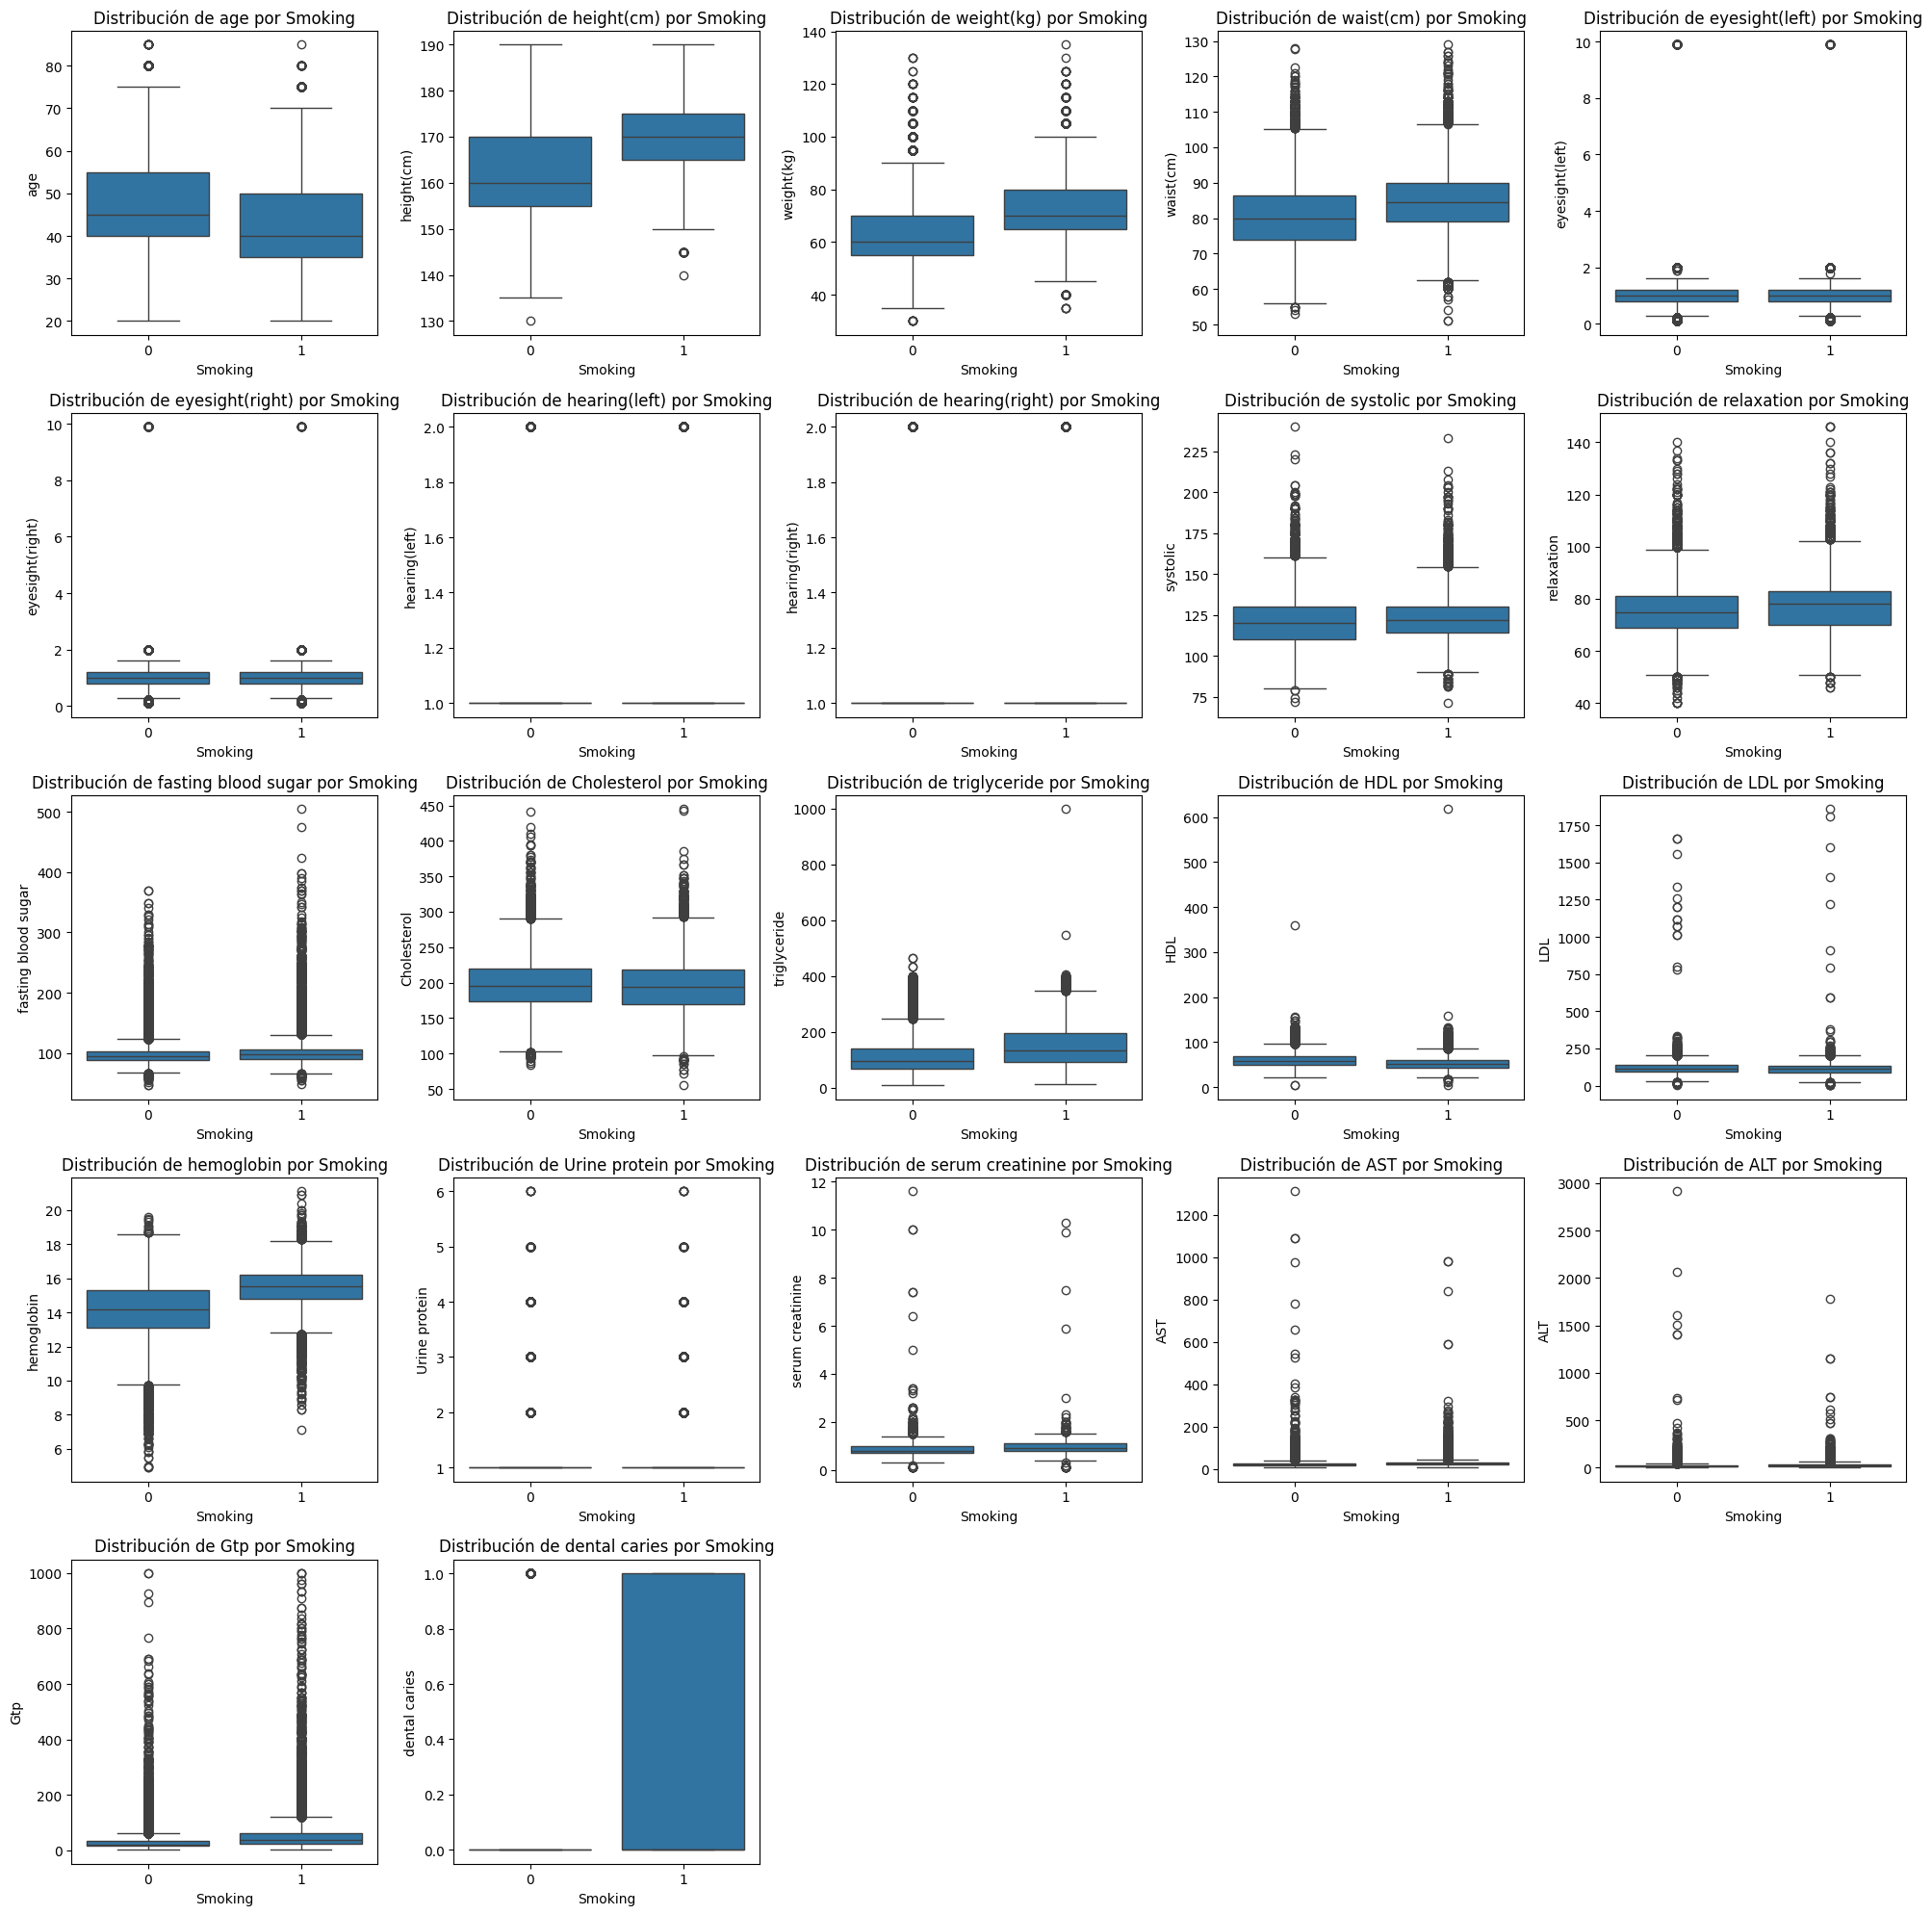

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns, excluding the target variable 'smoking' and already dropped columns
numerical_variables = df.select_dtypes(include=np.number).columns.tolist()
numerical_variables.remove('smoking')

# Define the number of columns for subplots
n_cols = 5
n_rows = (len(numerical_variables) + n_cols - 1) // n_cols

plt.figure(figsize=(20, n_rows * 4)) # Adjust figure size based on the number of rows

for i, variable in enumerate(numerical_variables):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x='smoking', y=variable, data=df)
    plt.title(f'Distribución de {variable} por Smoking')
    plt.xlabel('Smoking')
    plt.ylabel(variable)

plt.tight_layout()
plt.show()



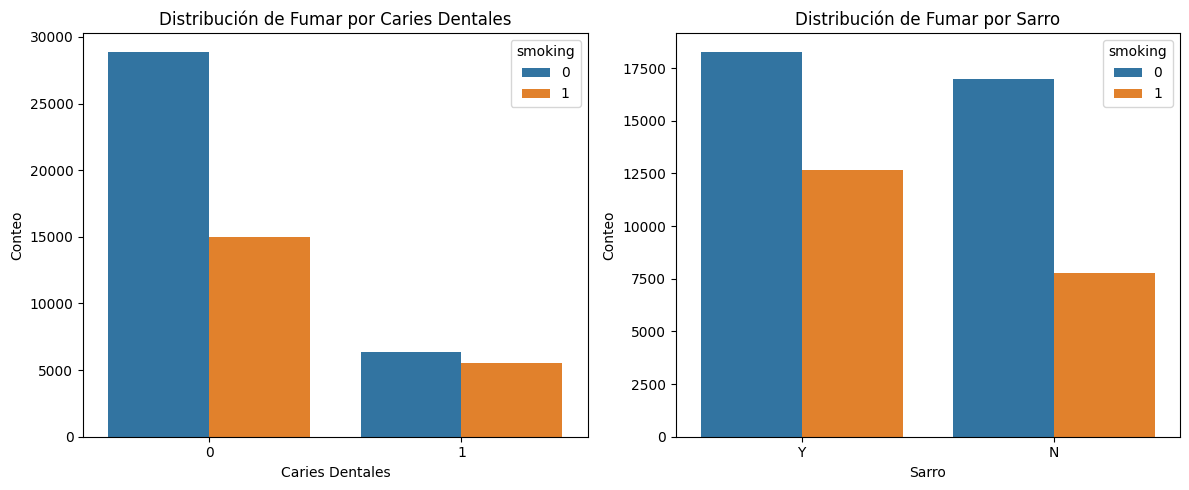

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='dental caries', hue='smoking', data=df, ax=axes[0])
axes[0].set_title('Distribución de Fumar por Caries Dentales')
axes[0].set_xlabel('Caries Dentales')
axes[0].set_ylabel('Conteo')

sns.countplot(x='tartar', hue='smoking', data=df, ax=axes[1])
axes[1].set_title('Distribución de Fumar por Sarro')
axes[1].set_xlabel('Sarro')
axes[1].set_ylabel('Conteo')

plt.tight_layout()
plt.show()

In [12]:

cat_features = ["gender","tartar"]
df = pd.get_dummies(df, columns=cat_features)


In [13]:
# Convertir a dummy (genero, sarro)
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

df.head()

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,serum creatinine,AST,ALT,Gtp,dental caries,smoking,gender_F,gender_M,tartar_N,tartar_Y
0,40,155,60,81.3,1.2,1.0,1.0,1.0,114.0,73.0,...,0.7,18.0,19.0,27.0,0,0,1,0,0,1
1,40,160,60,81.0,0.8,0.6,1.0,1.0,119.0,70.0,...,0.6,22.0,19.0,18.0,0,0,1,0,0,1
2,55,170,60,80.0,0.8,0.8,1.0,1.0,138.0,86.0,...,1.0,21.0,16.0,22.0,0,1,0,1,1,0
3,40,165,70,88.0,1.5,1.5,1.0,1.0,100.0,60.0,...,1.0,19.0,26.0,18.0,0,0,0,1,0,1
4,40,155,60,86.0,1.0,1.0,1.0,1.0,120.0,74.0,...,0.6,16.0,14.0,22.0,0,0,1,0,1,0


In [14]:
print("Shape:", df.shape)
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

Shape: (55692, 27)
Número de filas: 55692
Número de columnas: 27


In [15]:
scaler = StandardScaler()

2.BALANCEO DE LA DATA

In [16]:
smoking_distribution = df['smoking'].value_counts()
print("Distribución de la variable 'smoking':")
print(smoking_distribution)

Distribución de la variable 'smoking':
smoking
0    35237
1    20455
Name: count, dtype: int64


In [17]:
X = df.drop('smoking', axis=1)
y = df['smoking']
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (55692, 26)
Shape of y: (55692,)


In [18]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Distribución de la variable 'smoking' después de SMOTE:")
print(y_resampled.value_counts())

Distribución de la variable 'smoking' después de SMOTE:
smoking
0    35237
1    35237
Name: count, dtype: int64


3.PREPARACIÓN DE LOS DATOS

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

5.SELECCIÓN DE VARIABLES NUMÉRICAS

In [20]:
X_train.head()

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,gender_F,gender_M,tartar_N,tartar_Y
29276,45,155,60,83.800000,0.600000,1.000000,2.0,1.0,118.000000,78.000000,...,1.0,0.600000,27.000000,6.000000,23.000000,0,1,0,0,1
12808,50,155,50,71.000000,1.000000,1.200000,1.0,1.0,130.000000,85.000000,...,2.0,0.700000,24.000000,22.000000,22.000000,0,1,0,1,0
28316,25,160,60,76.500000,1.200000,1.200000,1.0,1.0,139.000000,86.000000,...,1.0,1.100000,24.000000,27.000000,34.000000,1,0,1,0,1
66005,72,165,69,89.962882,1.139109,1.357921,1.0,1.0,111.405939,61.014847,...,1.0,1.021782,27.594061,18.579214,26.564367,0,0,1,0,0
30163,20,175,80,86.000000,0.700000,0.200000,1.0,1.0,140.000000,79.000000,...,1.0,0.900000,17.000000,25.000000,26.000000,0,0,1,0,1


In [21]:

# summarize
print('Train', X_train.shape, y_train.shape)
print('Test', X_test.shape, y_test.shape)

Train (56379, 26) (56379,)
Test (14095, 26) (14095,)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.feature_selection import f_classif # Using f_classif as an example, you can also use mutual_info_classif
from sklearn.linear_model import LogisticRegression

# define the evaluation method
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

# define the pipeline to evaluate
model = LogisticRegression(solver='liblinear') # You can add max_iter here if needed
fs = SelectKBest(score_func=f_classif) # Choose your desired score_func

pipeline = Pipeline(steps=[('anova',fs), ('lr', model)]) # Name the steps appropriately

# define the grid of hyperparameters to search
grid = dict()
grid['anova__k'] = [i+1 for i in range(X_train.shape[1])] # Search over possible values of k

# define the grid search
search = GridSearchCV(pipeline, grid, scoring='accuracy', n_jobs=-1, cv=cv)

# perform the search
results = search.fit(X_train, y_train) # Fit on the training data

# summarize best
print('Best Mean Accuracy: %.3f' % results.best_score_)
print('Best Config: %s' % results.best_params_)

Best Mean Accuracy: 0.776
Best Config: {'anova__k': 18}


In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
import numpy as np

# define the evaluation method
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

# define the pipeline to evaluate
model = LogisticRegression(solver='liblinear')

# usar información mutua
fs = SelectKBest(score_func=mutual_info_classif)

pipeline = Pipeline(steps=[('mutual', fs), ('lr', model)])

# define the grid
grid = dict()
grid['mutual__k'] = list(range(1, X.shape[1] + 1))  # probar todos los k

# define the grid search
search = GridSearchCV(pipeline, grid, scoring='accuracy', n_jobs=-1, cv=cv)

# perform the search
results = search.fit(X, y)

# summarize best
print('Best Mean Accuracy: %.3f' % results.best_score_)
print('Best Config: %s' % results.best_params_)


Best Mean Accuracy: 0.746
Best Config: {'mutual__k': 23}


prueba F de ANOVA

Feature 0: 1961.234733
Feature 1: 12553.973545
Feature 2: 6147.352925
Feature 3: 3385.020073
Feature 4: 249.082355
Feature 5: 274.101160
Feature 6: 45.161682
Feature 7: 28.798951
Feature 8: 279.747248
Feature 9: 722.192610
Feature 10: 566.477715
Feature 11: 53.153772
Feature 12: 3812.443723
Feature 13: 2230.242281
Feature 14: 99.495793
Feature 15: 13350.622976
Feature 16: 5.289060
Feature 17: 3499.968413
Feature 18: 173.491098
Feature 19: 550.767364
Feature 20: 2987.596967
Feature 21: 14.399867
Feature 22: 27865.703278
Feature 23: 24235.259861
Feature 24: 2386.804494
Feature 25: 4.137883


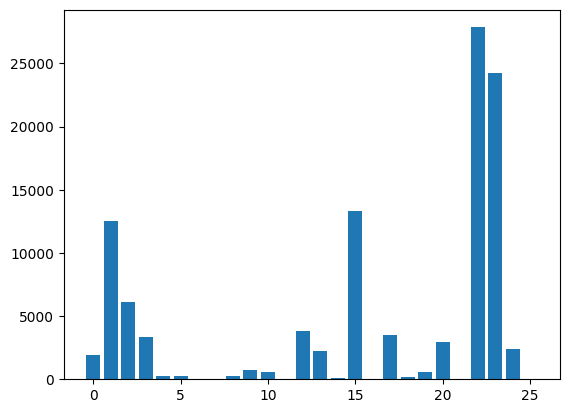

In [22]:
from sklearn.feature_selection import f_classif, SelectKBest
from matplotlib import pyplot

# define feature selection function
def select_features(X_train, y_train, X_test, score_func, k):
    # configure to select all features
    fs = SelectKBest(score_func=score_func, k=18)
    # learn relationship from training data
    fs.fit(X_train, y_train)
    # transform train input data
    X_train_fs = fs.transform(X_train)
    # transform test input data
    X_test_fs = fs.transform(X_test)
    return X_train_fs, X_test_fs, fs

# feature selection
X_train_fs, X_test_fs, fs = select_features(X_train, y_train, X_test, f_classif, 'all')

# what are scores for the features
for i in range(len(fs.scores_)):
  print('Feature %d: %f' % (i, fs.scores_[i]))

# plot the scores
pyplot.bar([i for i in range(len(fs.scores_))], fs.scores_)
pyplot.show()

Selección de funciones de información mutua

Feature 0: 0.101809
Feature 1: 0.184156
Feature 2: 0.138343
Feature 3: 0.163284
Feature 4: 0.129762
Feature 5: 0.133965
Feature 6: 0.014705
Feature 7: 0.007642
Feature 8: 0.146529
Feature 9: 0.151067
Feature 10: 0.150082
Feature 11: 0.143506
Feature 12: 0.172032
Feature 13: 0.159893
Feature 14: 0.146549
Feature 15: 0.235188
Feature 16: 0.021925
Feature 17: 0.165310
Feature 18: 0.145918
Feature 19: 0.162765
Feature 20: 0.205954
Feature 21: 0.001105
Feature 22: 0.193544
Feature 23: 0.174270
Feature 24: 0.025910
Feature 25: 0.002550


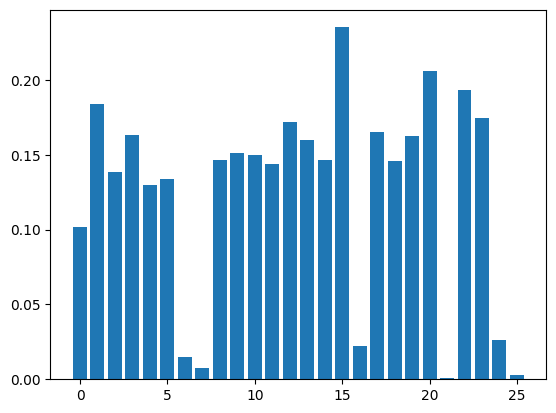

In [23]:
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from matplotlib import pyplot

# define feature selection function (reusing the previous one)
def select_features(X_train, y_train, X_test, score_func, k):
    # configure to select all features
    fs = SelectKBest(score_func=score_func, k=23)
    # learn relationship from training data
    fs.fit(X_train, y_train)
    # transform train input data
    X_train_fs = fs.transform(X_train)
    # transform test input data
    X_test_fs = fs.transform(X_test)
    return X_train_fs, X_test_fs, fs


# feature selection
X_train_fs, X_test_fs, fs = select_features(X_train, y_train, X_test, mutual_info_classif, 'all')

# what are scores for the features
for i in range(len(fs.scores_)):
  print('Feature %d: %f' % (i, fs.scores_[i]))

# plot the scores
pyplot.bar([i for i in range(len(fs.scores_))], fs.scores_)
pyplot.show()

Modelado con características seleccionadas

In [24]:
# fit the model
model = LogisticRegression(solver='liblinear', max_iter=1000)
model.fit(X_train, y_train)

# evaluate the model
yhat = model.predict(X_test)

# evaluate predictions
accuracy = accuracy_score(y_test, yhat)
print('Accuracy: %.2f' % (accuracy*100))

Accuracy: 77.83


Modelo construido utilizando características de la prueba F de ANOVA

In [25]:
# feature selection
X_train_fs, X_test_fs, fs = select_features(X_train, y_train, X_test, f_classif, 18)

# fit the model
model = LogisticRegression(solver='liblinear')
model.fit(X_train_fs, y_train)

# evaluate the model
yhat = model.predict(X_test_fs)

# evaluate predictions
accuracy = accuracy_score(y_test, yhat)
print('Accuracy: %.2f' % (accuracy*100))

Accuracy: 77.50


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Modelo construido utilizando características de información mutua

In [26]:
# feature selection
X_train_fs, X_test_fs, fs = select_features(X_train, y_train, X_test, mutual_info_classif, 23)

# fit the model
model = LogisticRegression(solver='liblinear')
model.fit(X_train_fs, y_train)

# evaluate the model
yhat = model.predict(X_test_fs)

# evaluate predictions
accuracy = accuracy_score(y_test, yhat)
print('Accuracy: %.2f' % (accuracy*100))

Accuracy: 77.57


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Ajuste el número de funciones seleccionadas

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold

# define the evaluation method
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

# define the pipeline to evaluate
model = LogisticRegression(solver='liblinear')

fs = SelectKBest(score_func=f_classif)

pipeline = Pipeline(steps=[('anova',fs), ('lr', model)])

# define the grid
grid = dict()
grid['anova__k'] = [i+1 for i in range(X.shape[1])]

# define the grid search
search = GridSearchCV(pipeline, grid, scoring='accuracy', n_jobs=-1, cv=cv)

# perform the search
results = search.fit(X, y)

# summarize best
print('Best Mean Accuracy: %.3f' % results.best_score_)
print('Best Config: %s' % results.best_params_)

Best Mean Accuracy: 0.746
Best Config: {'anova__k': 18}


In [28]:
from sklearn.model_selection import cross_val_score
from numpy import mean
from numpy import std

# evaluate a given model using cross-validation
def evaluate_model(model):
  cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
  scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
  return scores

>1 0.701 (0.005)
>2 0.701 (0.005)
>3 0.702 (0.005)
>4 0.703 (0.005)
>5 0.704 (0.005)
>6 0.726 (0.005)
>7 0.734 (0.005)
>8 0.735 (0.005)
>9 0.738 (0.005)
>10 0.739 (0.005)
>11 0.736 (0.006)
>12 0.738 (0.006)
>13 0.740 (0.006)
>14 0.740 (0.005)
>15 0.742 (0.007)
>16 0.743 (0.007)
>17 0.744 (0.006)
>18 0.746 (0.006)


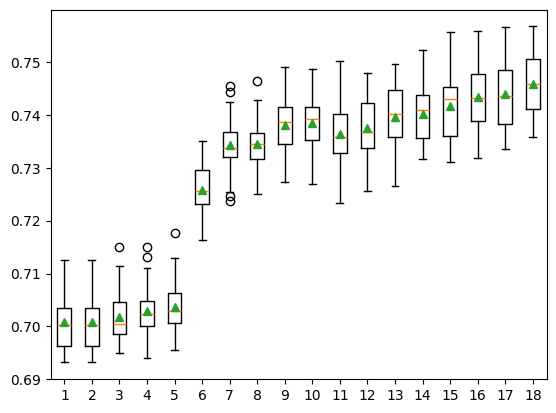

In [ ]:
from sklearn.model_selection import cross_val_score
from numpy import mean
from numpy import std

# evaluate a given model using cross-validation
def evaluate_model(model):
  cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
  scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
  return scores

# define number of features to evaluate
num_features = [i+1 for i in range(18)] # Changed to iterate up to 18 features

# enumerate each number of features
results = list()

for k in num_features:
  # create pipeline
  model = LogisticRegression(solver='liblinear')
  fs = SelectKBest(score_func=f_classif, k=k)
  pipeline = Pipeline(steps=[('anova',fs), ('lr', model)])
  # evaluate the model
  scores = evaluate_model(pipeline)
  results.append(scores)
  # summarize the results
  print('>%d %.3f (%.3f)' % (k, mean(scores), std(scores)))

# plot model performance for comparison
pyplot.boxplot(results, tick_labels=num_features, showmeans=True)
pyplot.show()

In [29]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select the top 18 features based on f_classif scores
selector = SelectKBest(score_func=f_classif, k=18)
X_selected = selector.fit_transform(X, y)

# Get the names of the selected features
selected_features_mask = selector.get_support()
selected_feature_names = X.columns[selected_features_mask]

# Create a new DataFrame with the selected features
X_selected_df = pd.DataFrame(X_selected, columns=selected_feature_names)

print("Data set", X_selected_df.shape)
display(X_selected_df.head())

Data set (55692, 18)


,age,height(cm),weight(kg),waist(cm),systolic,relaxation,fasting blood sugar,triglyceride,HDL,hemoglobin,serum creatinine,ALT,Gtp,dental caries,gender_F,gender_M,tartar_N,tartar_Y
0,40.0,155.0,60.0,81.3,114.0,73.0,94.0,82.0,73.0,12.9,0.7,19.0,27.0,0.0,1.0,0.0,0.0,1.0
1,40.0,160.0,60.0,81.0,119.0,70.0,130.0,115.0,42.0,12.7,0.6,19.0,18.0,0.0,1.0,0.0,0.0,1.0
2,55.0,170.0,60.0,80.0,138.0,86.0,89.0,182.0,55.0,15.8,1.0,16.0,22.0,0.0,0.0,1.0,1.0,0.0
3,40.0,165.0,70.0,88.0,100.0,60.0,96.0,254.0,45.0,14.7,1.0,26.0,18.0,0.0,0.0,1.0,0.0,1.0
4,40.0,155.0,60.0,86.0,120.0,74.0,80.0,74.0,62.0,12.5,0.6,14.0,22.0,0.0,1.0,0.0,1.0,0.0


PCA

In [30]:
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot

# get the dataset
# def get_dataset():
#     X, y = make_classification(n_samples=1000, n_features=25, n_informative=20, n_redundant=5, random_state=7)
#     return X, y

In [31]:
# get a list of models to evaluate
def get_models():
    models = dict()
    for i in range(1,21):
        steps = [('pca', PCA(n_components=i)), ('m', LogisticRegression())]
        models[str(i)] = Pipeline(steps=steps)
    return models

In [32]:
# evaluate a given model using cross-validation
def evaluate_model(model, X, y):
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
    scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
    return scores

>1 0.665 (0.004)
>2 0.672 (0.004)
>3 0.677 (0.004)
>4 0.679 (0.004)
>5 0.681 (0.005)
>6 0.688 (0.005)
>7 0.689 (0.005)
>8 0.697 (0.005)
>9 0.698 (0.005)
>10 0.697 (0.005)
>11 0.697 (0.005)
>12 0.708 (0.006)
>13 0.708 (0.006)
>14 0.711 (0.006)
>15 0.721 (0.007)
>16 0.724 (0.007)
>17 0.724 (0.007)
>18 0.724 (0.006)
>19 0.726 (0.007)
>20 0.727 (0.007)


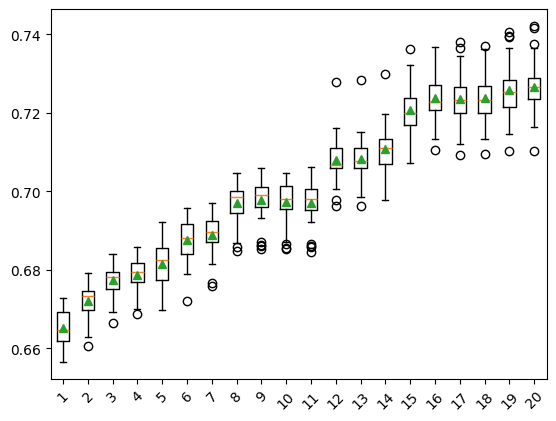

In [33]:
# define dataset
# X, y = get_dataset() # Commented out synthetic data generation

# get the models to evaluate
models = get_models()

# evaluate the models and store results
results, names = list(), list()
for name, model in models.items():
    scores = evaluate_model(model, X, y)
    results.append(scores)
    names.append(name)
    print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))

# plot model performance for comparison
pyplot.boxplot(results, tick_labels=names, showmeans=True)
pyplot.xticks(rotation=45)
pyplot.show()

In [34]:
# define dataset
# X, y = make_classification(n_samples=1000, n_features=25, n_informative=20, n_redundant=5, random_state=7) # Commented out synthetic data generation

# define the model
steps = [('pca', PCA(n_components=15)), ('m', LogisticRegression())]
model = Pipeline(steps=steps)

# fit the model on the whole dataset
model.fit(X, y)

# Extract the PCA step from the pipeline
pca_step = model.named_steps['pca']

# Transform the original data using the fitted PCA
X_pca_transformed = pca_step.transform(X)

# Create a DataFrame from the transformed data for better readability
pca_columns = [f'Principal_Component_{i+1}' for i in range(X_pca_transformed.shape[1])]
X_pca_transformed_df = pd.DataFrame(X_pca_transformed, columns=pca_columns)

print("Shape of the transformed dataset:", X_pca_transformed_df.shape)
display(X_pca_transformed_df.head())

Shape of the transformed dataset: (55692, 15)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Principal_Component_1,Principal_Component_2,Principal_Component_3,Principal_Component_4,Principal_Component_5,Principal_Component_6,Principal_Component_7,Principal_Component_8,Principal_Component_9,Principal_Component_10,Principal_Component_11,Principal_Component_12,Principal_Component_13,Principal_Component_14,Principal_Component_15
0,-45.376466,25.277976,10.187966,-7.472241,-13.813933,6.085219,-0.431928,-5.600813,-4.001450,3.091653,2.901098,-8.893363,1.396728,0.679617,-0.834919
1,-16.837175,12.675794,-14.202072,0.660585,28.822637,16.168572,-11.805400,-8.907089,0.557382,-1.386337,-12.797781,-4.520614,-4.054452,1.670645,-1.716160
2,51.480217,60.160200,-22.976066,-6.181492,-9.860633,-0.452120,7.433942,20.075395,-0.495123,-1.136468,-2.730079,11.102482,-0.508211,3.325469,0.540239
3,132.756460,162.025504,-20.369366,2.074055,-17.345896,-5.118137,-11.335866,-26.917455,0.569163,-13.197519,-2.724324,-1.523239,-3.587308,2.113355,-0.305412
4,-60.665680,-4.521645,-3.441430,-7.982044,-7.775544,-12.048923,2.119293,4.276000,-4.374631,-0.938504,1.137492,-11.125854,-0.691142,3.840362,-1.342046


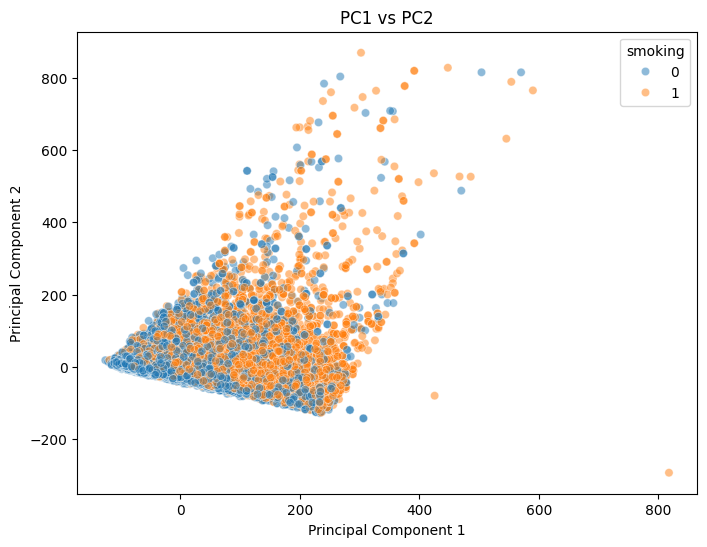

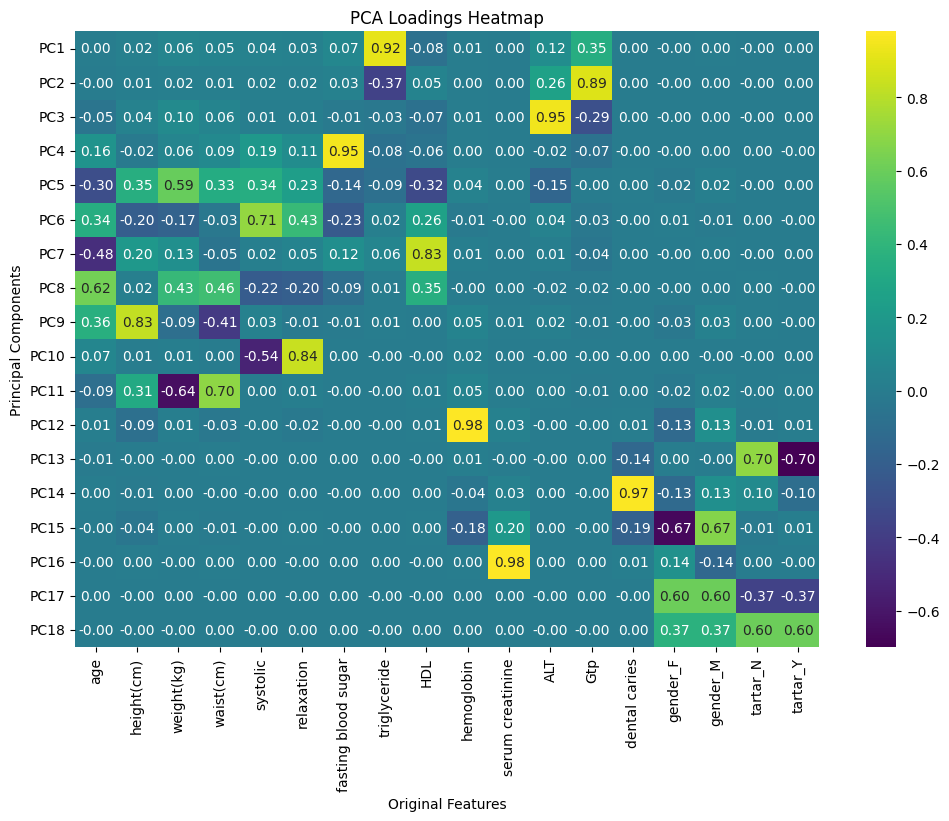

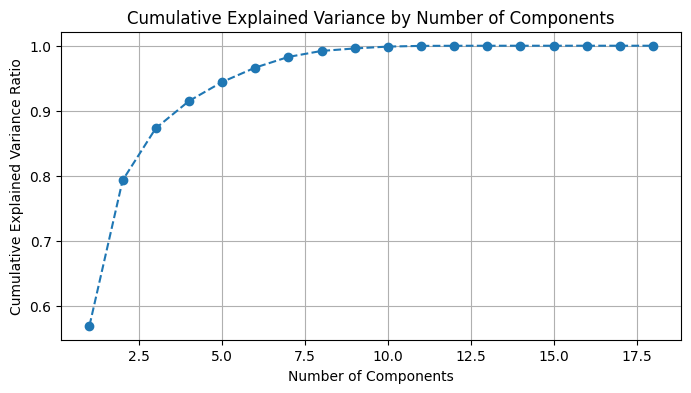

In [35]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Redefine X and y using the original dataframe to ensure correct lengths
X = df.drop('smoking', axis=1)
y = df['smoking']

# Perform PCA on the selected features (using X_selected_df from previous steps)
pca = PCA()
X_pca = pca.fit_transform(X_selected_df)

# Create a DataFrame with the principal components
pca_df = pd.DataFrame(data = X_pca, columns = [f'PC{i+1}' for i in range(X_pca.shape[1])])

# Add the target variable back to the PCA DataFrame for plotting
# Use the 'y' from the original dataset
pca_df['smoking'] = y

# Scatter plot of PC1 vs PC2
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='smoking', data=pca_df, alpha=0.5)
plt.title('PC1 vs PC2')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# Heatmap of loadings
plt.figure(figsize=(12, 8))
sns.heatmap(pca.components_, cmap='viridis', annot=True, fmt=".2f", xticklabels=X_selected_df.columns, yticklabels=[f'PC{i+1}' for i in range(pca.n_components_)])
plt.title('PCA Loadings Heatmap')
plt.xlabel('Original Features')
plt.ylabel('Principal Components')
plt.show()

# Explained variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = explained_variance_ratio.cumsum()

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.show()

# **Modelos**



Random Forest

Best Mean Accuracy: 0.855
Best Parameters: {'rf__max_depth': 20, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}
Classification Report for the Best Random Forest Model (Evaluated on Original Test Set):
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      6990
           1       0.97      1.00      0.98      7105

    accuracy                           0.98     14095
   macro avg       0.98      0.98      0.98     14095
weighted avg       0.98      0.98      0.98     14095



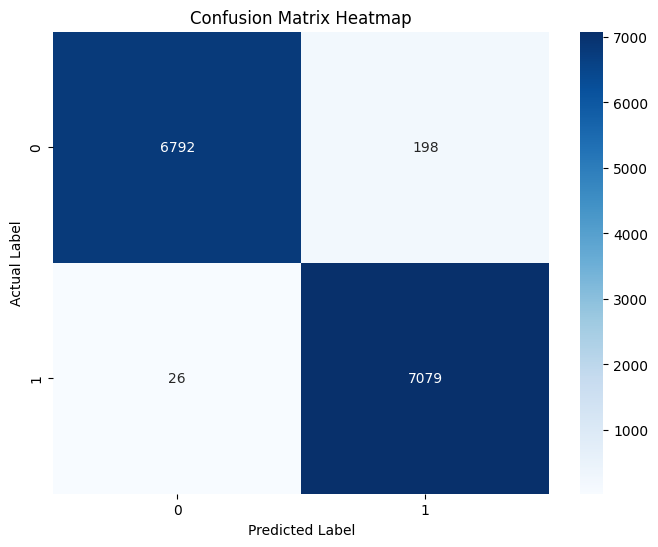

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2]
}

cv_rf = RepeatedStratifiedKFold(n_splits=3, n_repeats=2, random_state=42)
grid_search_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=cv_rf, scoring='accuracy', n_jobs=-1)

grid_search_rf.fit(X_resampled, y_resampled)

print('Best Mean Accuracy: %.3f' % grid_search_rf.best_score_)
print('Best Parameters: %s' % grid_search_rf.best_params_)

best_rf_model = grid_search_rf.best_estimator_
y_pred_best_rf_original_test = best_rf_model.predict(X_test)

print("Classification Report for the Best Random Forest Model (Evaluated on Original Test Set):")
print(classification_report(y_test, y_pred_best_rf_original_test))

conf_matrix_original_test = confusion_matrix(y_test, y_pred_best_rf_original_test)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_original_test, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

Extra-trees

Best Mean Accuracy: 0.817
Best Parameters: {'et__max_depth': 20, 'et__min_samples_leaf': 1, 'et__min_samples_split': 2, 'et__n_estimators': 200}
Classification Report for the Best Extra Trees Model (Evaluated on Original Test Set):
              precision    recall  f1-score   support

           0       0.97      0.78      0.87      6990
           1       0.82      0.97      0.89      7105

    accuracy                           0.88     14095
   macro avg       0.89      0.88      0.88     14095
weighted avg       0.89      0.88      0.88     14095



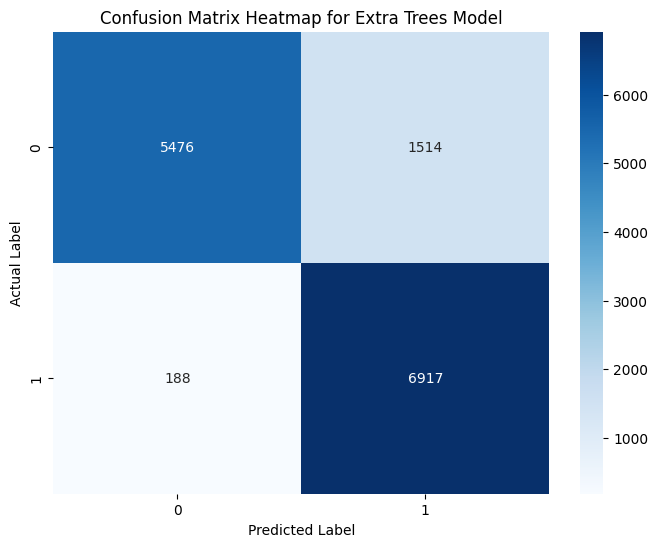

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


pipeline_et = Pipeline([
    ('scaler', StandardScaler()),
    ('et', ExtraTreesClassifier(random_state=42))
])

param_grid_et = {
    'et__n_estimators': [100, 200],
    'et__max_depth': [10, 20],
    'et__min_samples_split': [2, 5],
    'et__min_samples_leaf': [1, 2]
}

cv_et = RepeatedStratifiedKFold(n_splits=3, n_repeats=2, random_state=42)

grid_search_et = GridSearchCV(pipeline_et, param_grid_et, cv=cv_et, scoring='accuracy', n_jobs=-1)

grid_search_et.fit(X_resampled, y_resampled)

print('Best Mean Accuracy: %.3f' % grid_search_et.best_score_)
print('Best Parameters: %s' % grid_search_et.best_params_)

best_et_model = grid_search_et.best_estimator_
y_pred_best_et_original_test = best_et_model.predict(X_test)

print("Classification Report for the Best Extra Trees Model (Evaluated on Original Test Set):")
print(classification_report(y_test, y_pred_best_et_original_test))

conf_matrix_et_original_test = confusion_matrix(y_test, y_pred_best_et_original_test)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_et_original_test, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Heatmap for Extra Trees Model')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

SVM Linear

Best Mean Accuracy: 0.777
Best Parameters: {'svm__C': 0.1}

Classification Report for the Best SVM Linear Model (Evaluated on Original Test Set):
              precision    recall  f1-score   support

           0       0.88      0.63      0.74      6990
           1       0.72      0.92      0.80      7105

    accuracy                           0.78     14095
   macro avg       0.80      0.77      0.77     14095
weighted avg       0.80      0.78      0.77     14095



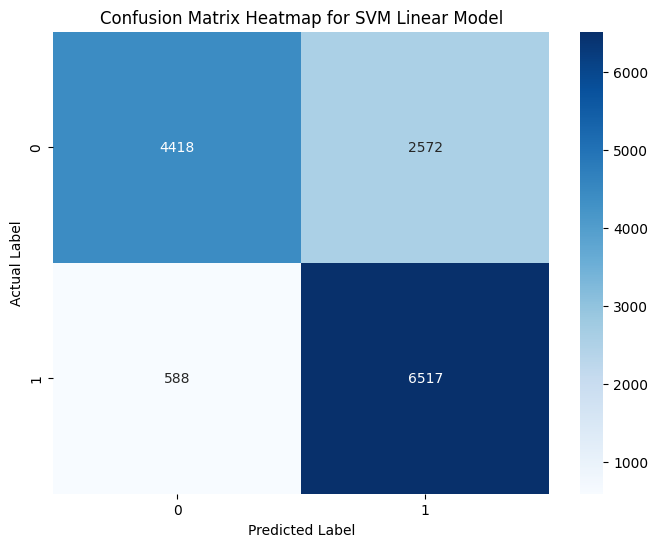

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(random_state=42, dual=False))
])

param_grid_svm = {
    'svm__C': [0.1, 1, 10]
}

cv_svm = RepeatedStratifiedKFold(n_splits=3, n_repeats=2, random_state=42)

grid_search_svm = GridSearchCV(pipeline_svm, param_grid_svm, cv=cv_svm, scoring='accuracy', n_jobs=-1)

grid_search_svm.fit(X_resampled, y_resampled)

print('Best Mean Accuracy: %.3f' % grid_search_svm.best_score_)
print('Best Parameters: %s' % grid_search_svm.best_params_)

best_svm_model = grid_search_svm.best_estimator_

y_pred_best_svm_original_test = best_svm_model.predict(X_test)

print("\nClassification Report for the Best SVM Linear Model (Evaluated on Original Test Set):")
print(classification_report(y_test, y_pred_best_svm_original_test))

conf_matrix_svm_original_test = confusion_matrix(y_test, y_pred_best_svm_original_test)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm_original_test, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Heatmap for SVM Linear Model')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

HistGradientBoosting

Best Mean Accuracy: 0.822
Best Parameters: {'hgb__learning_rate': 0.1, 'hgb__max_depth': None, 'hgb__max_iter': 200}

Classification Report for the Best HistGradientBoosting Model (Evaluated on Original Test Set):
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      6990
           1       0.84      0.89      0.86      7105

    accuracy                           0.86     14095
   macro avg       0.86      0.86      0.86     14095
weighted avg       0.86      0.86      0.86     14095


Confusion Matrix (Evaluated on Original Test Set):
[[5779 1211]
 [ 786 6319]]


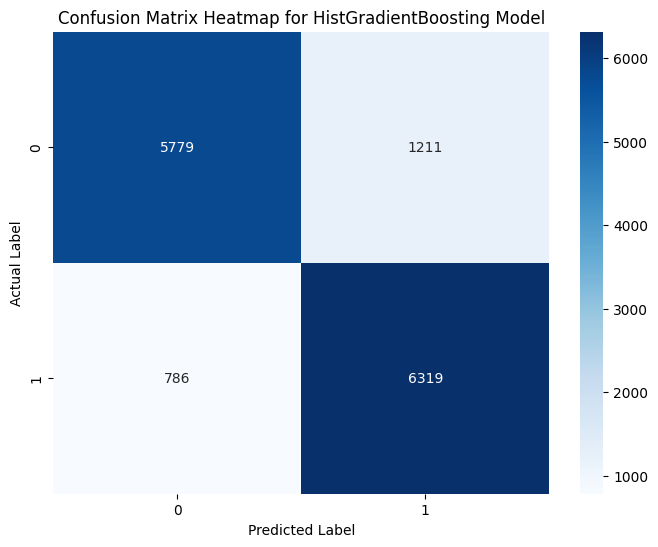

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

pipeline_hgb = Pipeline([
    ('scaler', StandardScaler()),
    ('hgb', HistGradientBoostingClassifier(random_state=42))
])

param_grid_hgb = {
    'hgb__max_iter': [100, 200],
    'hgb__max_depth': [None, 10],
    'hgb__learning_rate': [0.1, 0.01]
}

cv_hgb = RepeatedStratifiedKFold(n_splits=3, n_repeats=2, random_state=42)

grid_search_hgb = GridSearchCV(pipeline_hgb, param_grid_hgb, cv=cv_hgb, scoring='accuracy', n_jobs=-1)

grid_search_hgb.fit(X_resampled, y_resampled)

print('Best Mean Accuracy: %.3f' % grid_search_hgb.best_score_)
print('Best Parameters: %s' % grid_search_hgb.best_params_)

best_hgb_model = grid_search_hgb.best_estimator_

y_pred_best_hgb_original_test = best_hgb_model.predict(X_test)

print("\nClassification Report for the Best HistGradientBoosting Model (Evaluated on Original Test Set):")
print(classification_report(y_test, y_pred_best_hgb_original_test))

# Calculate and print the confusion matrix
conf_matrix_hgb_original_test = confusion_matrix(y_test, y_pred_best_hgb_original_test)
print("\nConfusion Matrix (Evaluated on Original Test Set):")
print(conf_matrix_hgb_original_test)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_hgb_original_test, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Heatmap for HistGradientBoosting Model')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

Logistics Regression

Best Mean Accuracy: 0.780
Best Parameters: {'lr__C': 100, 'lr__penalty': 'l2'}

Classification Report for the Best Logistic Regression Model (Evaluated on Original Test Set):
              precision    recall  f1-score   support

           0       0.86      0.66      0.75      6990
           1       0.73      0.89      0.80      7105

    accuracy                           0.78     14095
   macro avg       0.79      0.78      0.78     14095
weighted avg       0.79      0.78      0.78     14095



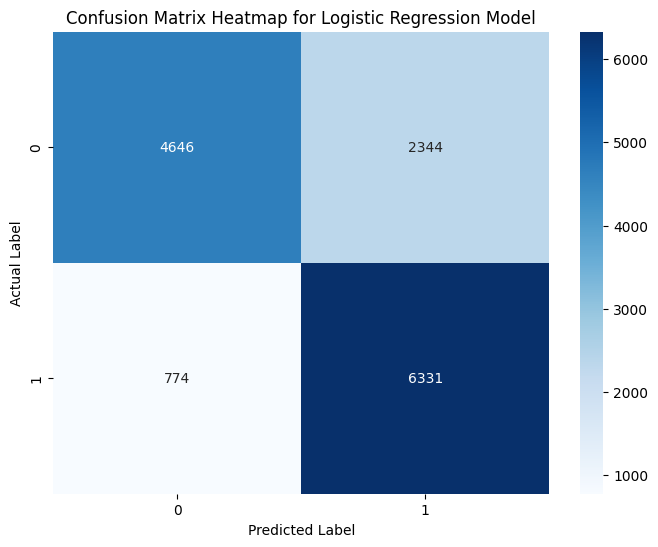

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression # Import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42, solver='liblinear'))
])

param_grid_lr = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2']
}

cv_lr = RepeatedStratifiedKFold(n_splits=3, n_repeats=2, random_state=42)

grid_search_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=cv_lr, scoring='accuracy', n_jobs=-1)

grid_search_lr.fit(X_resampled, y_resampled)


print('Best Mean Accuracy: %.3f' % grid_search_lr.best_score_)
print('Best Parameters: %s' % grid_search_lr.best_params_)

best_lr_model = grid_search_lr.best_estimator_

y_pred_best_lr_original_test = best_lr_model.predict(X_test)

print("\nClassification Report for the Best Logistic Regression Model (Evaluated on Original Test Set):")
print(classification_report(y_test, y_pred_best_lr_original_test))

conf_matrix_lr_original_test = confusion_matrix(y_test, y_pred_best_lr_original_test)


# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_lr_original_test, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Heatmap for Logistic Regression Model')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()